# Import Libraries

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler

SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)

2024-03-15 15:28:39.669895: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-15 15:28:39.726744: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-15 15:28:39.726788: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-15 15:28:39.727933: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-15 15:28:39.739178: I tensorflow/core/platform/cpu_feature_guar

# Load Data

In [2]:
df = pd.read_csv("./data.csv")
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


# Explore Data (EDA)

In [3]:
df.shape

(309, 16)

In [4]:
df.isna().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [5]:
df.duplicated().sum()

33

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(276, 16)

# Preprocessing

## Split Data

In [8]:
x, y = df.drop(columns=['LUNG_CANCER'], axis=1), df['LUNG_CANCER']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=SEED_VALUE)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.4, random_state=SEED_VALUE)
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(193, 15) (193,)
(49, 15) (49,)
(34, 15) (34,)


## Encoding Train

In [9]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
x_train['GENDER'] = enc.fit_transform(x_train['GENDER'])

In [10]:
x_test['GENDER'] = enc.transform(x_test['GENDER'])
x_val['GENDER'] = enc.transform(x_val['GENDER'])

## Encoding Test

In [11]:
y_train = enc.fit_transform(y_train)
y_test = enc.transform(y_test)
y_val= enc.transform(y_val)

## Create Tensor Dataset

In [12]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(32)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(32)

2024-03-15 15:28:42.864403: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-15 15:28:42.938384: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-15 15:28:42.938474: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-15 15:28:42.945688: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-15 15:28:42.945853: I external/local_xla/xla/stream_executor

# Modelling

## Sequential

In [13]:
inputs = tf.keras.Input(shape=(15,))
dense1 = Dense(8, activation='relu')(inputs)
dense2 = Dense(16, activation='relu')(dense1)
cat_layer = tf.keras.layers.Concatenate(axis=1)([dense1, dense2])
outputs = Dense(1, activation='sigmoid')(cat_layer)

In [14]:
funcModel = Model(inputs=inputs, outputs=outputs)
funcModel.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 15)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 8)                    128       ['input_1[0][0]']             
                                                                                                  
 dense_1 (Dense)             (None, 16)                   144       ['dense[0][0]']               
                                                                                                  
 concatenate (Concatenate)   (None, 24)                   0         ['dense[0][0]',               
                                                                     'dense_1[0][0]']         

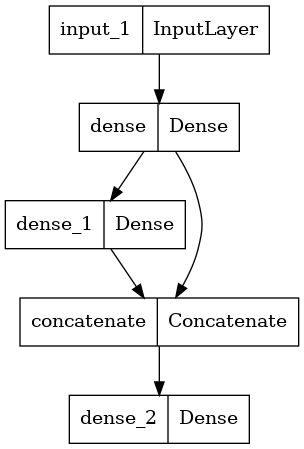

In [15]:
plot_model(funcModel)

In [16]:
funcModel.compile(loss=["binary_crossentropy"], optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), metrics=['accuracy'])

In [17]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, monitor='loss'),
]

history = funcModel.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=my_callbacks)

Epoch 1/100


2024-03-15 15:28:49.039100: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f24c03afc00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-03-15 15:28:49.039161: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2024-03-15 15:28:49.058916: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-03-15 15:28:49.139329: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1710491329.436705   12244 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/7 [==============================] - 5s 94ms/step - loss: 3.1959 - accuracy: 0.7358 - val_loss: 0.5609 - val_accuracy: 0.8571
Epoch 2/100
7/7 [==============================] - 0s 31ms/step - loss: 0.4702 - accuracy: 0.8705 - val_loss: 0.4105 - val_accuracy: 0.8571
Epoch 3/100
7/7 [==============================] - 0s 27ms/step - loss: 0.4058 - accuracy: 0.8705 - val_loss: 0.4641 - val_accuracy: 0.8571
Epoch 4/100
7/7 [==============================] - 0s 25ms/step - loss: 0.4263 - accuracy: 0.8705 - val_loss: 0.4345 - val_accuracy: 0.8571
Epoch 5/100
7/7 [==============================] - 0s 27ms/step - loss: 0.3938 - accuracy: 0.8705 - val_loss: 0.4110 - val_accuracy: 0.8571
Epoch 6/100
7/7 [==============================] - 0s 27ms/step - loss: 0.3859 - accuracy: 0.8705 - val_loss: 0.4101 - val_accuracy: 0.8571
Epoch 7/100
7/7 [==============================] - 0s 21ms/step - loss: 0.3865 - accuracy: 0.8705 - val_loss: 0.4125 - val_accuracy: 0.8571
Epoch 8/100
7/7 [===============

## Model Evaluation

### Train and Test Loss Graph

In [18]:
import matplotlib.pyplot as plt

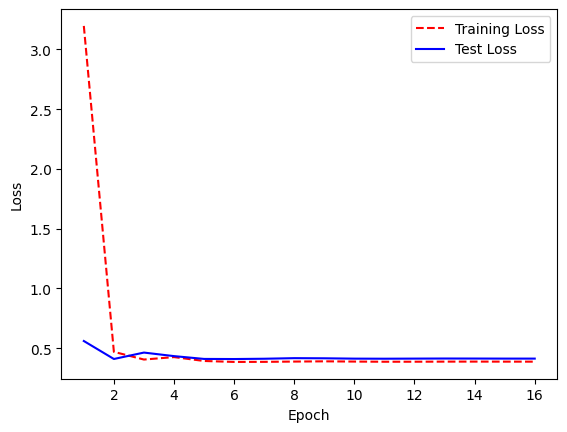

In [19]:
training_loss = history.history['loss']
test_loss = history.history['val_loss']

# Create count of the number of epochs
epoch_count = range(1, len(training_loss) + 1)

# Visualize loss history
plt.plot(epoch_count, training_loss, 'r--')
plt.plot(epoch_count, test_loss, 'b-')
plt.legend(['Training Loss', 'Test Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show();

From the graph above we can conclude that the model has achieved convergence at epoch 60 (i guess). with the training loss and validation loss near equal. The model has achieved mse of 28.991 on the training dataset and 41.603 on the validation dataset. With the R2 score of the model is 0.7366 with the test dataset.